# Classification

## Wine Quality Prediction

In [34]:
from pathlib import Path
import pickle

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 6)

## 1. Load Cleaned Dataset

In [35]:
data_path = Path('../data/processed/winequality_cleaned.csv')
plot_dir = Path('../plots/classification')
plot_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(data_path)

print(f'Dataset shape: {df.shape}')
display(df.head())

Dataset shape: (1019, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5


## 2. Feature and Target Separation

In [36]:
X = df.drop(columns='quality')
y = df['quality']

print(f'Feature matrix shape: {X.shape}')
print(f'Target vector shape: {y.shape}')
display(y.value_counts().sort_index().to_frame(name='count'))

Feature matrix shape: (1019, 11)
Target vector shape: (1019,)


,count
quality,
3,3
4,33
5,434
6,423
7,115
8,11


## 3. Train-Test Split

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')

X_train shape: (815, 11)
X_test shape: (204, 11)


## 4. Feature Scaling

In [38]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 5. Model Training and Evaluation

Three classification models are trained and compared:
- Logistic Regression
- K-Nearest Neighbors
- Random Forest


In [39]:
models = {
    'Logistic Regression': (LogisticRegression(max_iter=1000), X_train_scaled, X_test_scaled),
    'K-Nearest Neighbors': (KNeighborsClassifier(n_neighbors=5), X_train_scaled, X_test_scaled),
    'Random Forest': (RandomForestClassifier(n_estimators=200, random_state=42), X_train, X_test)
}

results = []
trained_models = {}

for name, (model, X_train_input, X_test_input) in models.items():
    model.fit(X_train_input, y_train)
    y_pred = model.predict(X_test_input)
    accuracy = accuracy_score(y_test, y_pred)
    results.append({'Model': name, 'Accuracy': accuracy})
    trained_models[name] = {'model': model, 'y_pred': y_pred}

results_df = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
display(results_df)

,Model,Accuracy
0,Random Forest,0.632353
1,Logistic Regression,0.598039
2,K-Nearest Neighbors,0.549020


## 6. Best Model Analysis

In [40]:
best_model_name = results_df.loc[0, 'Model']
best_model = trained_models[best_model_name]['model']
best_y_pred = trained_models[best_model_name]['y_pred']

print(f'Best model: {best_model_name}')
print(f'Accuracy: {results_df.loc[0, "Accuracy"]:.4f}')

Best model: Random Forest
Accuracy: 0.6324


In [41]:
report = classification_report(y_test, best_y_pred, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).transpose()
display(report_df)

,precision,recall,f1-score,support
4,0.000000,0.000000,0.000000,7.000000
5,0.698925,0.747126,0.722222,87.000000
6,0.584158,0.694118,0.634409,85.000000
7,0.500000,0.217391,0.303030,23.000000
8,0.000000,0.000000,0.000000,2.000000
accuracy,0.632353,0.632353,0.632353,0.632353
macro avg,0.356617,0.331727,0.331932,204.000000
weighted avg,0.597843,0.632353,0.606509,204.000000


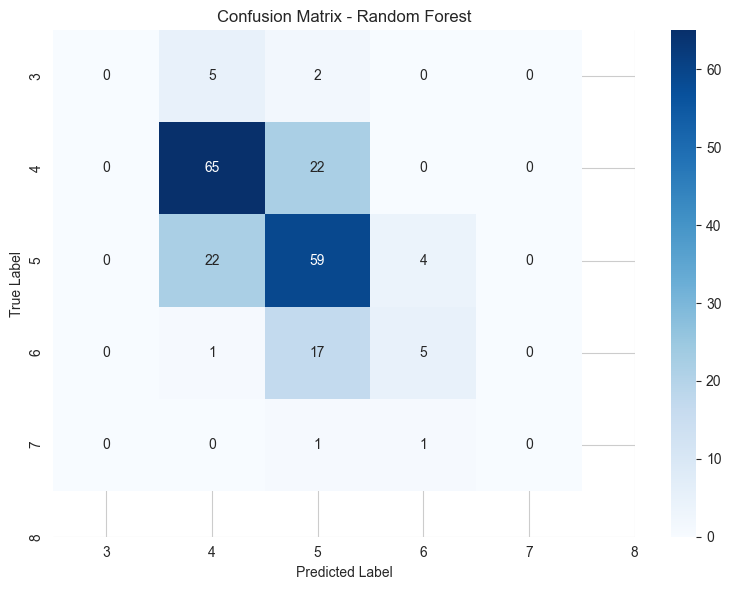

In [42]:
cm = confusion_matrix(y_test, best_y_pred)
labels = sorted(y.unique())

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig(plot_dir / 'confusion_matrix_best_model.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Save Best Model

In [43]:
models_dir = Path('../models')
models_dir.mkdir(parents=True, exist_ok=True)

model_bundle = {
    'model_name': best_model_name,
    'model': best_model,
    'feature_columns': X.columns.tolist(),
    'scaler': scaler if best_model_name in ['Logistic Regression', 'K-Nearest Neighbors'] else None
}

model_path = models_dir / 'best_classification_model.pkl'

with open(model_path, 'wb') as f:
    pickle.dump(model_bundle, f)

print(f'Best model saved to: {model_path}')

Best model saved to: ..\models\best_classification_model.pkl


## 8. Load Saved Model and Test

In [44]:
with open(model_path, 'rb') as f:
    loaded_bundle = pickle.load(f)

loaded_model_name = loaded_bundle['model_name']
loaded_model = loaded_bundle['model']
loaded_scaler = loaded_bundle['scaler']

if loaded_scaler is not None:
    X_test_for_loaded_model = loaded_scaler.transform(X_test)
else:
    X_test_for_loaded_model = X_test

loaded_y_pred = loaded_model.predict(X_test_for_loaded_model)
loaded_accuracy = accuracy_score(y_test, loaded_y_pred)

print(f'Loaded model: {loaded_model_name}')
print(f'Accuracy after loading: {loaded_accuracy:.4f}')

Loaded model: Random Forest
Accuracy after loading: 0.6324


## 9. Predict One Sample Wine

In [45]:
sample_index = X_test.index[0]
sample_features = X_test.loc[[sample_index]]
actual_quality = y_test.loc[sample_index]

if loaded_scaler is not None:
    sample_input = loaded_scaler.transform(sample_features)
else:
    sample_input = sample_features

predicted_quality = loaded_model.predict(sample_input)[0]

print('Sample wine features:')
display(sample_features)
print(f'Actual quality: {actual_quality}')
print(f'Predicted quality: {predicted_quality}')

Sample wine features:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
652,7.4,0.965,0.0,2.2,0.088,16.0,32.0,0.99756,3.58,0.67,10.2


Actual quality: 5
Predicted quality: 5
